<a href="https://colab.research.google.com/github/jesildabraganca0511/NLP/blob/main/mini-projects/week1_sms_spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub


In [2]:
path=kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [3]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('/kaggle/input/sms-spam-collection-dataset/spam.csv', encoding='latin-1')


In [8]:
df[:4]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN


In [9]:
df=df[["v1","v2"]]

In [17]:
df.columns = ['label', 'message']


In [18]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


check for null values

In [11]:
df.isnull().sum()

,0
v1,0
v2,0


check for duplicates

In [14]:
df.duplicated().sum()

np.int64(403)

clean dupliactes

In [15]:
df.drop_duplicates(keep='first',inplace=True)

check imbalance

In [30]:
df["label"].value_counts()

,count
label,
ham,4516
spam,653


In [31]:
df['message'] = df["message"].str.lower()

In [21]:
import re

In [32]:
df['message'] = df['message'].apply(lambda x: re.sub(r'[^\w\s]', '', x))


In [33]:
import spacy

In [34]:
nlp=spacy.load("en_core_web_sm")

In [42]:
def tokenize_message(raw_text):
  doc = nlp(raw_text)
  tokens = [token.lemma_ for token in doc
            if not token.is_stop and not token.is_punct and token.is_alpha]
  return tokens

In [43]:
df["message_tokens"]=df["message"].apply(tokenize_message)

In [44]:
df.head()

,label,message,message_tokens
0,ham,go until jurong point crazy available only in ...,"[jurong, point, crazy, available, bugis, n, gr..."
1,ham,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,ham,u dun say so early hor u c already then say,"[u, dun, early, hor, u, c]"
4,ham,nah i dont think he goes to usf he lives aroun...,"[nah, not, think, go, usf, live]"


stringing it together

In [45]:
df["processed_message"]= df["message_tokens"].apply(lambda x: " ".join(x))

In [47]:
df.head()

,label,message,message_tokens,processed_message
0,ham,go until jurong point crazy available only in ...,"[jurong, point, crazy, available, bugis, n, gr...",jurong point crazy available bugis n great wor...
1,ham,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]",ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, wkly, comp, win, fa, cup, final,...",free entry wkly comp win fa cup final tkts tex...
3,ham,u dun say so early hor u c already then say,"[u, dun, early, hor, u, c]",u dun early hor u c
4,ham,nah i dont think he goes to usf he lives aroun...,"[nah, not, think, go, usf, live]",nah not think go usf live


In [48]:
df_final = df[['label', 'processed_message']].copy()
display(df_final.head())

,label,processed_message
0,ham,jurong point crazy available bugis n great wor...
1,ham,ok lar joking wif u oni
2,spam,free entry wkly comp win fa cup final tkts tex...
3,ham,u dun early hor u c
4,ham,nah not think go usf live


Feature Extraction / Experimentation

In [49]:
from sklearn.feature_extraction.text import CountVectorizer

In [57]:
cv=CountVectorizer()
X_bow=cv.fit_transform(df_final["processed_message"])

In [58]:
print("Matrix Shape:")
print(X_bow.shape)

# Display the first 20 unique words the vectorizer learned for its master vocabulary
print("\nFirst 20 Vocabulary Words:")
print(cv.get_feature_names_out()[:20])

Matrix Shape:
(5169, 6907)

First 20 Vocabulary Words:
['aa' 'aah' 'aaniye' 'aaooooright' 'aathilove' 'aathiwhere' 'ab' 'abbey'
 'abdoman' 'abeg' 'abel' 'aberdeen' 'abi' 'ability' 'abiola' 'abj' 'able'
 'abnormally' 'abouta' 'abroad']


In [59]:
print(X_bow.toarray())


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [64]:
tfidf=TfidfVectorizer()
X=tfidf.fit_transform(df_final["processed_message"])

In [65]:
print("TF-IDF Matrix Shape:")
print(X.shape)

# Display a sample of the first 20 unique words the vectorizer chose for the vocabulary
print("\nFirst 20 TF-IDF Vocabulary Words:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF Matrix Shape:
(5169, 6907)

First 20 TF-IDF Vocabulary Words:
['aa' 'aah' 'aaniye' 'aaooooright' 'aathilove' 'aathiwhere' 'ab' 'abbey'
 'abdoman' 'abeg' 'abel' 'aberdeen' 'abi' 'ability' 'abiola' 'abj' 'able'
 'abnormally' 'abouta' 'abroad']


In [66]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder object
encoder = LabelEncoder()

# Learn the unique text labels in our dataset and convert them into numbers
# This transforms our "ham" and "spam" labels into 0s and 1s and saves them as y
y = encoder.fit_transform(df['label'])

In [67]:
df_final

,label,processed_message
0,ham,jurong point crazy available bugis n great wor...
1,ham,ok lar joking wif u oni
2,spam,free entry wkly comp win fa cup final tkts tex...
3,ham,u dun early hor u c
4,ham,nah not think go usf live
...,...,...
5567,spam,time try contact u u win pound prize claim eas...
5568,ham,ì b go esplanade fr home
5569,ham,pity mood soany suggestion
5570,ham,guy bitching act like d interested buy week gi...


Modelling

In [70]:
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print("Data loaded successfully! Ready to train.")


Features shape: (5169, 6907)
Labels shape: (5169,)
Data loaded successfully! Ready to train.


In [78]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing sets
# X should be the raw processed messages (strings), not the already vectorized matrix
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df_final["processed_message"], y, test_size=0.2, random_state=42)

# Verify the dimensions and type of our new datasets
print("--- Training Data Shape (raw messages) ---")
print(X_train_raw.shape)
print(f"Type of X_train_raw: {type(X_train_raw)}")
print("\n--- Testing Data Shape (raw messages) ---")
print(X_test_raw.shape)
print(f"Type of X_test_raw: {type(X_test_raw)}")

--- Training Data Shape (raw messages) ---
(4135,)
Type of X_train_raw: <class 'pandas.core.series.Series'>

--- Testing Data Shape (raw messages) ---
(1034,)
Type of X_test_raw: <class 'pandas.core.series.Series'>


In [79]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression()),
])

In [80]:
text_clf.fit(X_train_raw, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LogisticRegression())])

In [83]:
y_pred=text_clf.predict(X_test_raw)

In [84]:
y_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0])

Evaluation

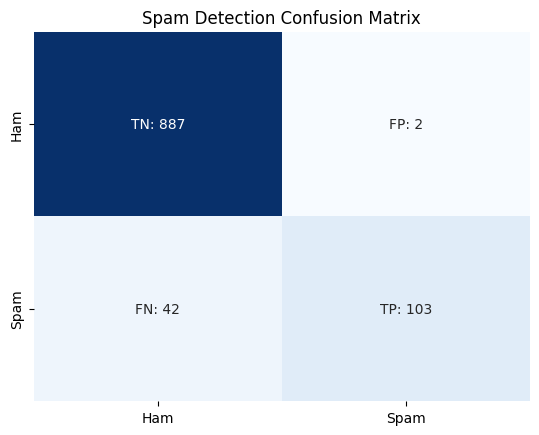

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the matrix and define the labels in a compact format
cm = confusion_matrix(y_test, y_pred)
labels = [[f"TN: {cm[0,0]}", f"FP: {cm[0,1]}"], [f"FN: {cm[1,0]}", f"TP: {cm[1,1]}"]]

# Plot the heatmap
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'], cbar=False)
plt.title('Spam Detection Confusion Matrix')
plt.show()

In [86]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy by comparing our pre-loaded predictions to the true answers
test_accuracy = accuracy_score(y_test, y_pred)

# Print the final score formatted as a percentage
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9574468085106383


In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate and print the advanced classification metrics
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))

Precision: 0.9809523809523809
Recall:    0.7103448275862069
F1 Score:  0.824
